# Bab 1: Eksplorasi Data Analisis (EDA) & Preprocessing

Dokumen ini memuat analisis kualitas data (missing values, tipe data, ukuran), visualisasi univariat/multivariat, dan dokumentasi preprocessing untuk 18 kelas gestur tangan berbasis koordinat hand landmarks MediaPipe.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

print("[+] Library berhasil diimpor!")

[+] Library berhasil diimpor!


## 1. Memuat Dataset

In [2]:
data_path = '../data/processed/hand_landmarks_data_clean.csv'
df = pd.read_csv(data_path)
print(f"[+] Dataset berhasil dimuat dengan ukuran: {df.shape}")

[+] Dataset berhasil dimuat dengan ukuran: (25675, 64)


## 2. Analisis Kualitas Data
Kita memeriksa statistik deskriptif dasar, tipe data, dan apakah ada data kosong (*missing values*).

In [3]:
print("--- Informasi Dataset ---")
print(df.info())

print("\n--- Cek Missing Values ---")
missing = df.isnull().sum().sum()
print(f"Total Missing Values: {missing}")

--- Informasi Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-nu

## 3. Distribusi Kelas Gestur (Univariat)
Menampilkan jumlah sampel untuk masing-masing dari 18 kelas gestur.

C:\Users\Asus\AppData\Local\Temp\ipykernel_14968\3497780818.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette='viridis')


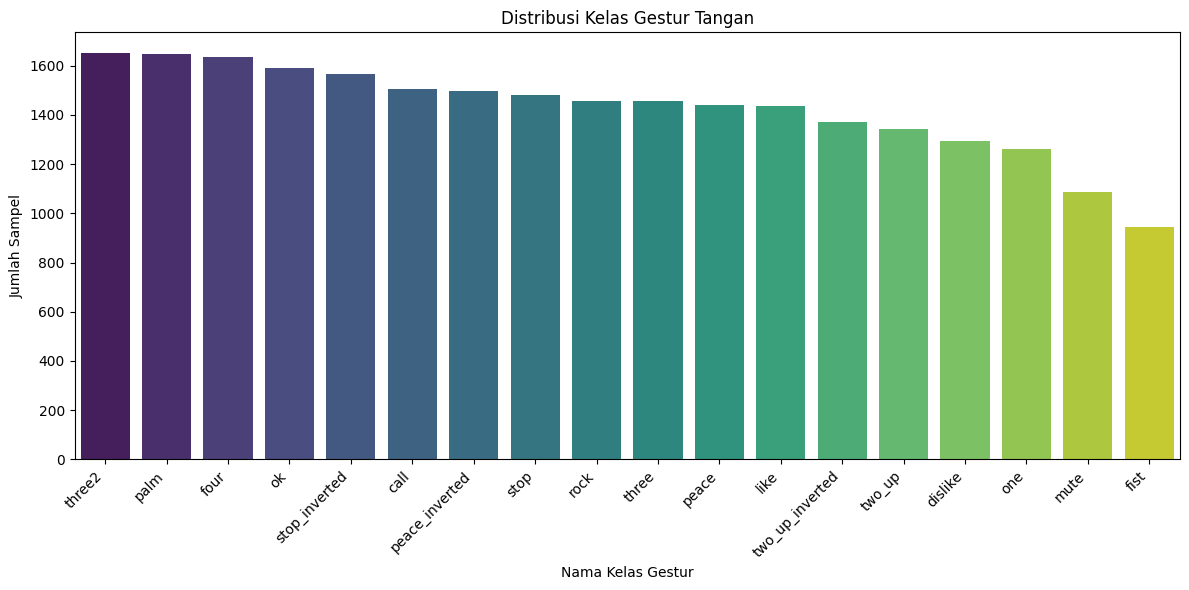

In [4]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Distribusi Kelas Gestur Tangan')
plt.xlabel('Nama Kelas Gestur')
plt.ylabel('Jumlah Sampel')
plt.tight_layout()
plt.show()

## 4. Visualisasi Multivariat (Sebaran Koordinat Spasial)
Kita memplot hubungan koordinat X dan Y pada pergelangan tangan (`x1, y1`) untuk melihat sebaran spasial posisi tangan saat direkam.

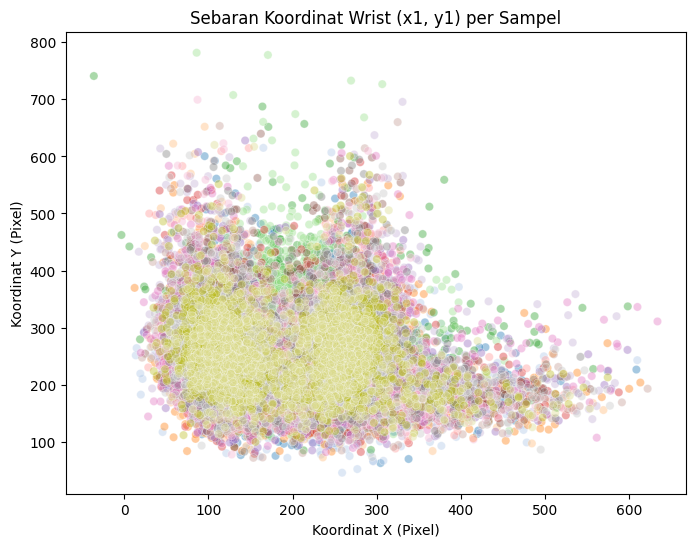

In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='x1', y='y1', hue='label', legend=False, alpha=0.4, palette='tab20')
plt.title('Sebaran Koordinat Wrist (x1, y1) per Sampel')
plt.xlabel('Koordinat X (Pixel)')
plt.ylabel('Koordinat Y (Pixel)')
plt.show()

## 5. Dokumentasi Preprocessing & Justifikasi
1. **Missing Values Handling:** Tidak ada nilai kosong di dataset karena data yang tidak terdeteksi landmark oleh MediaPipe langsung diabaikan saat proses penulisan file mentah.
2. **Label Encoding:** Dilakukan encoding dari kelas target teks menjadi integer numerik.
3. **Data Splitting:** Data dibagi menjadi 80% train dan 20% test untuk menghindari bias evaluasi.